In [1]:
import pandas as pd

# read each CSV as a *Series* (1‑D) instead of a DataFrame
en  = pd.read_csv("errors/en_errors_retuned.csv",  header=None).iloc[:, 0]
xgb = pd.read_csv("errors/xgb_errors_retuned.csv", header=None).iloc[:, 0]
nn  = pd.read_csv("errors/nn_errors_retuned.csv",  header=None).iloc[:, 0]
gpr = pd.read_csv("errors/gpr_errors_tuned.csv",  header=None).iloc[:, 0]

# stick them side‑by‑side and get the correlation matrix
err_df = pd.concat([en, xgb, nn, gpr], axis=1) #
err_df.columns = ["en", "xgb", "nn", "gpr"]    #     # nice column names

corr = err_df.corr()                                   # Pearson by default
print(corr)

           en       xgb        nn       gpr
en   1.000000 -0.031782 -0.185360 -0.009007
xgb -0.031782  1.000000  0.026483 -0.050812
nn  -0.185360  0.026483  1.000000 -0.139930
gpr -0.009007 -0.050812 -0.139930  1.000000


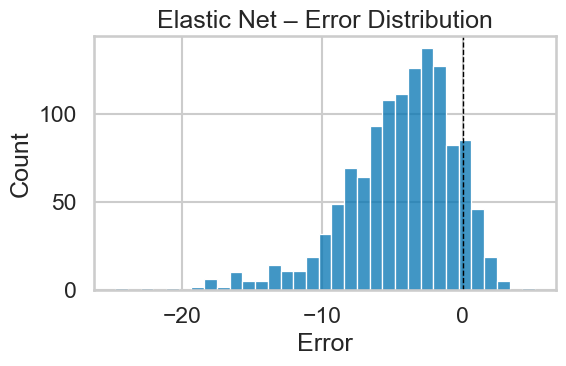

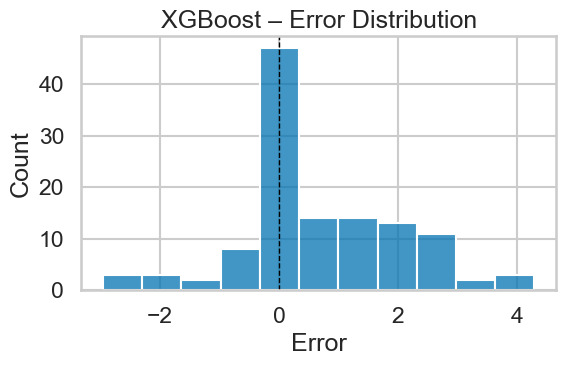

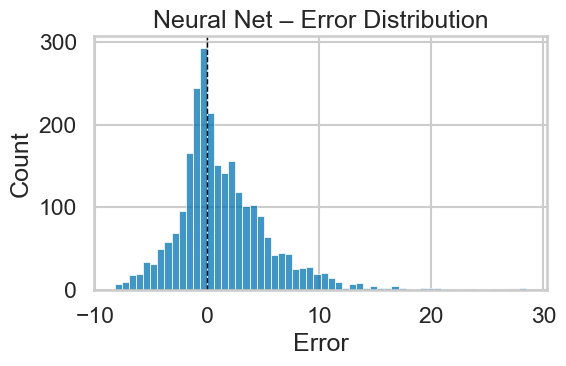

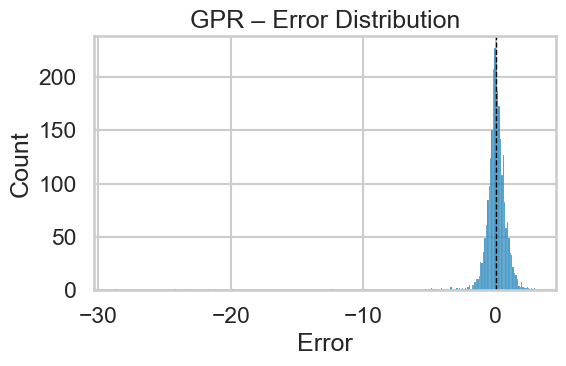

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------------------------------------
# 1. Put the Series in a dictionary to loop over
# ---------------------------------------------
error_series = {
    "Elastic Net" : en,
    "XGBoost"     : xgb,
    "Neural Net"  : nn,
    "GPR": gpr
}

sns.set(style="whitegrid", palette="colorblind", context="talk")  # nicer look

# ---------------------------------------------
# 2. One figure per series
# ---------------------------------------------
for name, s in error_series.items():
    plt.figure(figsize=(6, 4))             # new figure each time
    sns.histplot(s,
                 bins="auto",              # or choose an int, e.g. bins=30
                 kde=False,                 # add KDE curve
                 color=sns.color_palette()[0])

    plt.title(f"{name} – Error Distribution")
    plt.xlabel("Error")
    plt.ylabel("Count")
    plt.axvline(0, color="black", ls="--", lw=1)  # reference line at zero
    plt.tight_layout()

    # OPTIONAL: save to file
    # fname = name.lower().replace(" ", "_") + "_hist.png"
    # plt.savefig(fname, dpi=300)

    plt.show()                            # displays the current figure